In [24]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt


df=pd.read_csv(r"/Users/suriya/Ukesh_AIML_Projects/Amazon Music Clustering/Data/single_genre_artists.csv")
sample_df=df.copy()
sample_df.drop(['id_songs','name_song','name_artists'],axis=1,inplace=True)

feature_columns=['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness','liveness', 'valence', 'tempo']
featured_df=df[feature_columns]


scaler=StandardScaler()
scaled_df=scaler.fit_transform(featured_df)
scaled_df=pd.DataFrame(scaled_df,columns=featured_df.columns)

pca=PCA(n_components=6)
x_pca=pca.fit_transform(scaled_df)

model=KMeans(n_clusters=3,random_state=42)
labels=model.fit_predict(x_pca)
#print(f"Num_Cluster:{3}, Silhoutte_score:{silhouette_score(x_pca,labels)}")

df['Clusters']=labels
cluster_names={
    0: "Acoustic and Calm Tracks",
    1: "Energetic Tracks",
    2: "Speech Oriented Tracks"
}
df["Cluster_Profile"]=df["Clusters"].map(cluster_names)
df.to_csv(r"/Users/suriya/Ukesh_AIML_Projects/Amazon Music Clustering/Data/Amazon_Music_Clustering.csv",index=False)
print("Success")

Success


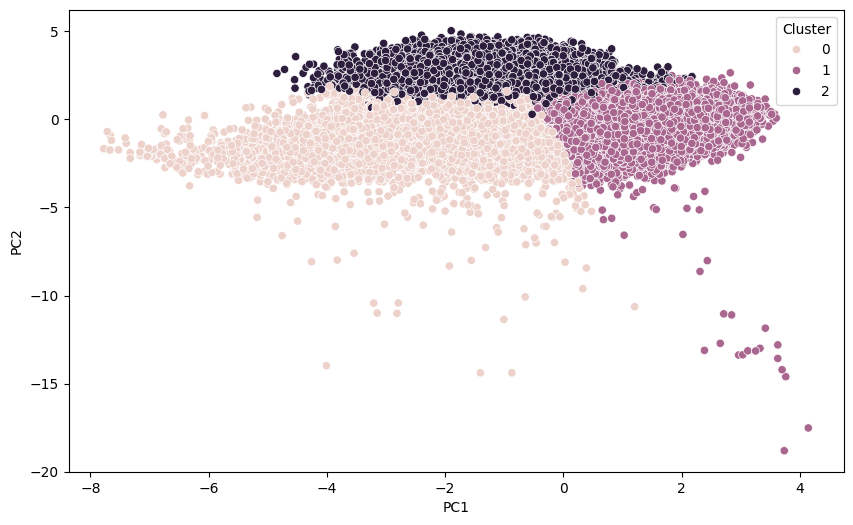

In [25]:
plot_df=pd.DataFrame(x_pca[:, :2], columns=["PC1", "PC2"])
plot_df["Cluster"]=labels

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster")

plt.show()

In [28]:
df.sort_values(["Clusters","popularity_songs"],ascending=[True,False]).groupby("Cluster_Profile").head(5)

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists,Clusters,Cluster_Profile
35233,1Xi84slp6FryDSCbzq4UCD,Arcade,89,183624,0,3klZnJvYGIbWritVwQD434,2019-03-07,0.450,0.329,9,...,0.1350,0.266,71.884,3,181450.0,['dutch pop'],Duncan Laurence,80,0,Acoustic and Calm Tracks
35436,6AGOKlMZWLCaEJGnaROtF9,Put Your Records On,87,210463,0,7MPGCB854Qo4alYMOPkBka,2020-04-24,0.399,0.491,6,...,0.1100,0.151,91.066,4,92599.0,['bedroom pop'],Ritt Momney,73,0,Acoustic and Calm Tracks
34858,5vjLSffimiIP26QG5WcN2K,Hold On,83,198853,0,5D3muNJhYYunbRkh3FKgX0,2017-02-03,0.618,0.443,2,...,0.0829,0.167,119.949,4,99345.0,['acoustic pop'],Chord Overstreet,70,0,Acoustic and Calm Tracks
35234,1J14CdDAvBTE1AJYUOwl6C,Arcade,83,185147,0,3klZnJvYGIbWritVwQD434,2020-11-12,0.453,0.350,9,...,0.1440,0.279,72.017,3,181450.0,['dutch pop'],Duncan Laurence,80,0,Acoustic and Calm Tracks
35463,1xqRKo0SDFDO5Jy8yEVD0X,ROLLIN N CONTROLLIN FREESTYLE,83,191209,1,22hWz22JAmIhIEp0u1X01L,2020-08-07,0.690,0.514,8,...,0.3460,0.307,72.791,4,135164.0,['new york drill'],DUSTY LOCANE,72,0,Acoustic and Calm Tracks
35665,3Ofmpyhv5UAQ70mENzB277,Astronaut In The Ocean,98,132780,0,1uU7g3DNSbsu0QjSEqZtEd,2021-01-06,0.778,0.695,4,...,0.1500,0.472,149.996,4,177401.0,['australian hip hop'],Masked Wolf,85,1,Energetic Tracks
35398,27OeeYzk6klgBh83TSvGMA,WITHOUT YOU,94,161385,1,2tIP7SsRs7vjIcLrU85W8J,2020-11-06,0.662,0.413,0,...,0.1340,0.467,93.005,4,1624015.0,['australian hip hop'],The Kid LAROI,90,1,Energetic Tracks
35422,3VvA1wSxukMLsvXoXtlwWx,Hecha Pa' Mi,92,186133,0,2NfSBtmWe7oPw1EmetJVso,2020-07-31,0.725,0.756,4,...,0.1030,0.828,100.070,4,224299.0,[],Boza,78,1,Energetic Tracks
35241,1tkg4EHVoqnhR6iFEXb60y,What You Know Bout Love,91,160000,1,0eDvMgVFoNV3TpwtrVCoTj,2020-07-03,0.709,0.548,10,...,0.1330,0.543,83.995,4,5076597.0,['brooklyn drill'],Pop Smoke,92,1,Energetic Tracks
35532,2TksvaRivgAEj780DgRB73,911,91,215891,1,77ziqFxp5gaInVrF2lj4ht,2021-02-05,0.795,0.655,7,...,0.2960,0.744,93.029,4,7865082.0,"['latin', 'panamanian pop', 'reggaeton', 'trap...",Sech,89,1,Energetic Tracks


In [30]:
for clust in sorted(df['Cluster_Profile'].unique()):
    df[df['Cluster_Profile']==clust].to_csv(f"/Users/suriya/Ukesh_AIML_Projects/Amazon Music Clustering/Data/{clust}.csv",index=False)
